## Import Libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Load the dataset

In [3]:
df=pd.read_csv("/home/home/code/Susanta2025-lab/Fatocheck/data/raw/WELFake_Dataset.csv", index_col=0)

In [4]:
df.head()

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,NaN,Did they post their votes for Hillary already?,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 72134 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   71576 non-null  object
 1   text    72095 non-null  object
 2   label   72134 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.2+ MB


In [6]:
df.label.value_counts()

label
1    37106
0    35028
Name: count, dtype: int64

In [7]:
df["label"].value_counts()

label
1    37106
0    35028
Name: count, dtype: int64

In [8]:
df.head(1)

,title,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1


In [9]:
df.shape

(72134, 3)

## Data Cleaning

In [10]:
df.isnull().sum()

title    558
text      39
label      0
dtype: int64

In [11]:
df.iloc[0]

title    LAW ENFORCEMENT ON HIGH ALERT Following Threat...
text     No comment is expected from Barack Obama Membe...
label                                                    1
Name: 0, dtype: object

## Combining Title and Text Columns

In [12]:
df["content"] = (df["title"].fillna("") + " " + df["text"].fillna("")).str.strip()

In [13]:
df = df[['content', 'label']]

In [14]:
df.iloc[0]

content    LAW ENFORCEMENT ON HIGH ALERT Following Threat...
label                                                      1
Name: 0, dtype: object

In [15]:
df.isnull().sum()

content    0
label      0
dtype: int64

## Distribution of Fake vs Real News

In [19]:
print(df[df["label"]==1].head(1))

                                             content  label
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...      1


In [20]:
print(df.iloc[0]["content"])

LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to  turn the tide  and kill white people and cops to send a message about the killing of black people in America.One of the F***YoFlag organizers is called  Sunshine.  She has a radio blog show hosted from Texas called,  Sunshine s F***ing Opinion Radio Show. A snapshot of her #FYF911 @LOLatWhiteFear Twitter page at 9:53 p.m. shows that she was urging supporters to  Call now!! #fyf911 tonight we continue to dismantle the illusion of white Below is a SNAPSHOT Twitter Radio Call Invite   #FYF911The radio show aired at 10:00 p.m. eastern standard time.During the show, callers clearly call for  lynching  and  killing  of white people.A 2:39

## Reversing the Labels of the dataset

In [21]:
# As we can see the label 1 is for fake news and label 0 is for real news. We are reversing the labels to make it more intuitive. So, we will replace 1 with 0 and 0 with 1.
# df['label'] = df['label'].replace({1: 0, 0: 1}) or
df['label'] = 1-df['label']

In [22]:
df["label"].value_counts()

label
0    37106
1    35028
Name: count, dtype: int64

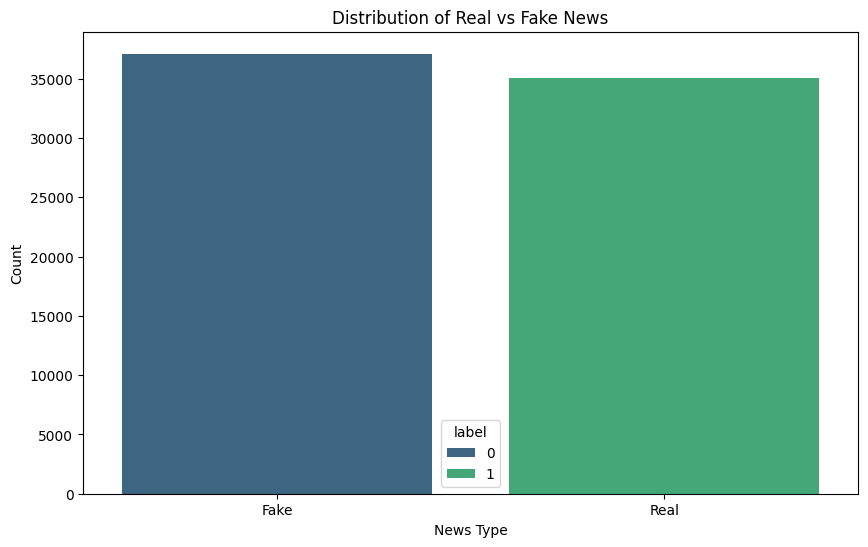

In [24]:

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='label',
    hue='label',
    palette= 'viridis'
    )

plt.title('Distribution of Real vs Fake News')
plt.xlabel('News Type')
plt.ylabel('Count')
plt.xticks([0,1], ['Fake', 'Real'])
plt.show()